# STEP 8. 평가: configurational 네트워크인가, 거리 네트워크의 변형인가?

**질문**: 각 정의의 공원 그래프가 **근접성(proximity)으로 환원되지 않는** 정보를 담고 있는가?

| 검증 | 방법 | 해석 |
|---|---|---|
- **D(보행거리)**는 근접성 자체를 정의로 쓰므로 판정 대상이 아니라 기준선이다(AUC는 정의상 1에 가까움).

| 거리-각도 상관 | Spearman($A_{ij}$, 최단 네트워크 거리), Spearman($A_{ij}$, 유클리드 간격) | 1에 가까우면 각도 = 거리 |
| **Proximity AUC** | 후보 쌍 중 edge 여부를 "가까울수록 edge"로 예측할 때의 AUC. 두 가지로 보고: `AUC_all`(최단거리 ≤ 3200 m 전체)과 **`AUC_condR`(설정의 탐색 한계 R 안의 쌍만)** | **AUC_condR 중앙값 > 0.85면 근접성 지배** |
| 밀도 맞춘 거리 null | edge 수가 같도록 가장 가까운 쌍만 연결한 그래프 → 연결요소 ARI, 고립 공원 일치 | 낮을수록 거리와 다른 묶음 |
| 사례 | "멀지만 연결된 쌍"과 "가깝지만 연결되지 않은 쌍" | 해석 가능한 구체 사례 |
| 고립 요인 모델 | IsolationPersistence ~ 면적, 둘레, attachment 수, OSM 완전성, regime, 유형 | 크기·데이터 품질이 고립을 기계적으로 결정하는지 |

**출력**: `evaluation_summary.csv`, `evaluation_cases.csv`, `isolation_model.txt`

In [1]:
# ===== 공통 설정 (모든 STEP 노트북에서 동일) =====
import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

# 분석 지역: "Brooklyn"(파일럿) 또는 "NYC"(전체). 환경변수 PARK_STUDY_AREA로도 지정 가능.
STUDY_AREA = os.environ.get("PARK_STUDY_AREA", "Brooklyn")

ROOT = Path.cwd()
DATA = ROOT / "Data"
PARKS_PATH = DATA / "NYCPark" / "Parks_Properties_20260923.geojson"
NET_DIR = DATA / "derived" / "network"        # STEP1 결과 (지역 무관, NYC+버퍼 전체)
AREA_DIR = DATA / "derived" / STUDY_AREA      # STEP2 이후 결과
OUT_DIR = ROOT / "outputs" / STUDY_AREA
for _d in (NET_DIR, AREA_DIR, OUT_DIR):
    _d.mkdir(parents=True, exist_ok=True)

CRS = 32618            # UTM 18N (m)
R_MAX = 3200           # 탐색 한계 (m) = 보로 네트워크 버퍼 폭
SPEED = 1.0            # speed_m_s=1 -> agg_seconds == 경로 길이(m)

BOROUGHS = {"M": "Manhattan", "X": "Bronx", "B": "Brooklyn", "Q": "Queens", "R": "Staten Island"}
AREA_BOROUGHS = ["B"] if STUDY_AREA == "Brooklyn" else list(BOROUGHS)

# 네트워크 변형: C = 가로 중심선 + 보행전용 경로 (주 분석), S = 보도 포함 전체 보행망 (민감도)
VARIANTS = ["C", "S"]
PRIMARY = "C"
SIDEWALK_FOOTWAYS = {"sidewalk", "crossing", "traffic_island"}

# 공원 필터 (사용자 결정): Flagship + 비공원성 필지 제외, 면적 상한 100 acres (계산은 200 상위집합)
EXCLUDE_TYPES = ["Flagship Park", "Operations", "Lot", "Undeveloped",
                 "Buildings/Institutions", "Cemetery", "Managed Sites"]
AREA_CAP = 100
AREA_CAP_SUPERSET = 200
AREA_CAP_GRID = [50, 100, 200]
RESTRICTED_TYPES = ["Garden", "Jointly Operated Playground"]            # 접근 제한 민감도
STREET_EMBEDDED_TYPES = ["Triangle/Plaza", "Strip", "Mall", "Parkway"]  # 가로 매몰형 민감도

# 공원-네트워크 attachment
ATTACH_BUFFER = {"C": 20.0, "S": 10.0}   # 경계 버퍼 (m): C는 중심선이 도로 폭 절반만큼 떨어져 있음
ATTACH_BUFFER_GRID = {"C": [15.0, 20.0, 30.0], "S": [5.0, 10.0, 20.0]}
INSIDE_SHARE = 0.9       # 공원 내부에 90% 이상 들어간 세그먼트는 attachment에서 제외 (통행은 허용)
K_SOURCES = 8            # 공원당 출발 attachment 최대 개수 (farthest-point sampling)
SMALL_COMPONENT = 200    # 이보다 작은 연결요소에만 붙은 공원은 'unresolved'

# 최종 묶음 공통 절차: 설정별 Louvain(γ) → 보로 단위 퍼콜레이션 필터 → 합의 ≥ 0.5 → 도보 10분 지름 분할
MAIN_GAMMA = 2
COMMERCIAL_BUFFER = 100   # 연구 개요: 군집 구성 공원 주변 100 m = 상업 영역

# 묶음 크기 제약: 묶음 안 모든 공원 쌍이 서로 도보 10분 이내 (보행망 최단거리, 1.33 m/s × 600 s ≈ 800 m)
WALK_LIMIT = 800
WALK_LIMIT_GRID = [400, 800, 1200]   # 5 / 10 / 15분 민감도

# N1 angular few-turn
N1_THETAS = [15, 45, 90, 180]
N1_RADII = [800, 1600, 3200]
N1_REL_Q = [0.1, 0.2]
DIST_BANDS = [0, 200, 400, 800, 1600, 3200]

# D walking distance (근접성 기준선): 보행망 최단거리 ≤ d 이면 연결
D_DISTS = [200, 400, 800]

# N2 street-axis continuity: 같은 연속 가로(stroke) 위, 두 공원 구간 사이 간격 ≤ lim
N2_ALONG = [400, 800, 1600]
# (큰길 속성 계산용) 각도 choice/NACH 반경과 상위 비율
N2_RADII = [800, 1600, 3200]
N2_TOP_P = [0.02, 0.05, 0.10]
STROKE_ANGLE = 30
STROKE_ANGLE_GRID = [20, 30, 45]
N2_MAX_ALONG = [3200, None]

# N3 excess few-turn field overlap
N3_THETAS = [45, 90]
N3_RADII = [800, 1600]
N3_TAU = [0.1, 0.2]
N3_KAPPA = [1.0, 1.25]

print(f"STUDY_AREA={STUDY_AREA}  boroughs={AREA_BOROUGHS}  AREA_DIR={AREA_DIR.relative_to(ROOT)}")

STUDY_AREA=NYC  boroughs=['M', 'X', 'B', 'Q', 'R']  AREA_DIR=Data/derived/NYC


In [2]:
import networkx as nx
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
from sklearn.metrics import roc_auc_score, adjusted_rand_score
from scipy.stats import spearmanr
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

GR_DIR = AREA_DIR / "graphs"
parks = gpd.read_parquet(NET_DIR / "parks.parquet")
cls = pd.read_parquet(GR_DIR / "classification.parquet")
settings = pd.read_csv(GR_DIR / "settings.csv")["setting"]
edges = pd.concat([pd.read_parquet(GR_DIR / f"edges_{d}.parquet") for d in ["N1", "N2", "N3"]], ignore_index=True)
EDGE_GROUPS = dict(tuple(edges.groupby("setting")))
DEF_CFG = f"d{int(ATTACH_BUFFER[PRIMARY])}_K{K_SOURCES}"
PIDS = sorted(cls[(cls.cap == AREA_CAP) & (cls.variant == PRIMARY)].park_id.unique())
pid_set = set(PIDS)

# 후보 쌍: 최단 네트워크 거리(기본 cfg, 대칭)와 유클리드 간격
pp = pd.read_parquet(AREA_DIR / f"pairs_{PRIMARY}.parquet")
pp = pp[(pp.cfg == DEF_CFG) & pp.i.isin(pid_set) & pp.j.isin(pid_set)]
lo, hi = np.minimum(pp.i, pp.j), np.maximum(pp.i, pp.j)
pp = pp.assign(i=lo, j=hi).groupby(["i", "j"]).agg({"D_net": "min", "A_800": "min", "A_1600": "min", "A_3200": "min"})
e0 = pd.read_parquet(NET_DIR / "pairs_E0.parquet")
e0_keys = set(zip(e0.loc[(e0[f"shared_{PRIMARY}"] > 0) | e0.touch, "i"], e0.loc[(e0[f"shared_{PRIMARY}"] > 0) | e0.touch, "j"]))
def same_parent_pairs(parks):
    """같은 원래 공원(선형 공원 구간)끼리의 쌍: 공원 자신과의 관계이므로 E0처럼 제외."""
    pcs = parks[parks.get("is_piece", False) == True] if "is_piece" in parks else parks.iloc[:0]
    out = set()
    for _, ids in pcs.groupby("parent_id").groups.items():
        ids = sorted(ids)
        out |= {(a, b) for k, a in enumerate(ids) for b in ids[k + 1:]}
    return out


e0_keys |= same_parent_pairs(parks)
pp = pp[[k not in e0_keys for k in pp.index]]
geom = parks.geometry
pp["D_euc"] = [geom[i].distance(geom[j]) for i, j in pp.index]
print(f"candidate pairs (both focal, not E0, D_net ≤ {R_MAX}): {len(pp):,}")

candidate pairs (both focal, not E0, D_net ≤ 3200): 100,884


## 8-1. 각도 비용과 거리의 상관

In [3]:
corr_rows = []
for r in N1_RADII:
    ok = pp[f"A_{r}"].notna()
    corr_rows.append({"R": r, "n": int(ok.sum()),
                      "spearman(A, D_net)": spearmanr(pp.loc[ok, f"A_{r}"], pp.loc[ok, "D_net"])[0],
                      "spearman(A, D_euc)": spearmanr(pp.loc[ok, f"A_{r}"], pp.loc[ok, "D_euc"])[0]})
pd.DataFrame(corr_rows).round(3)

,R,n,"spearman(A, D_net)","spearman(A, D_euc)"
0,800,9921,0.421,0.226
1,1600,29516,0.436,0.331
2,3200,95584,0.548,0.473


## 8-2. Proximity AUC와 밀도 맞춘 거리 null 비교
각 설정(주 변형, 상한 100)의 edge 집합을 두 가지로 평가한다.
- **AUC**: 후보 쌍 중 edge 여부를 $-D_{net}$로 예측할 때의 AUC
  - `AUC_all`: 최단거리 ≤ 3200 m인 모든 쌍이 후보. **R이 800 m인 설정은 edge가 정의상 800 m 안에만 생기므로 이 값이 기계적으로 부풀려진다.**
  - `AUC_condR`: 설정의 탐색 한계 R 안의 쌍만 후보(N1abs: R, N2: 가로 간격 한계 lim, N3: 2R(catchment 두 개), D: d, N1rel: 3200 m). CLAUDE.md에서 거리는 **탐색 한계**로 허용되므로, 올바른 질문은 "한계 안에서 거리가 여전히 연결을 결정하는가?"이다. **판정은 이 값으로 한다.**
- **거리 null**: 같은 edge 수 m개를 $D_{net}$이 가장 작은 m개 쌍으로 만든 그래프와 비교
  - `edge_jaccard`: 두 edge 집합의 Jaccard
  - `ARI_components`: 연결요소 라벨의 ARI
  - `iso_agree`: 고립 공원 집합의 Jaccard

In [4]:
def components(nodes, e):
    G = nx.Graph()
    G.add_nodes_from(nodes)
    G.add_edges_from(e)
    lab = {}
    for k, comp in enumerate(nx.connected_components(G)):
        for n in comp:
            lab[n] = k
    return pd.Series(lab).reindex(nodes)


cand = pp.sort_values("D_net")
cand_keys = list(cand.index)
eval_rows = []
for s in settings:
    parts = s.split("|")
    d, v = parts[0], parts[1]
    if v != PRIMARY or ((d.startswith("N1") or d == "D") and parts[2] != DEF_CFG):
        continue
    e = EDGE_GROUPS.get(s)
    if e is None or len(e) == 0:
        eval_rows.append({"setting": s, "definition": d, "edges": 0})
        continue
    e = e[e.i.isin(pid_set) & e.j.isin(pid_set)]
    ek = set(zip(np.minimum(e.i, e.j), np.maximum(e.i, e.j)))
    y = np.array([k in ek for k in cand_keys])
    auc = roc_auc_score(y, -cand["D_net"].values) if 0 < y.sum() < len(y) else np.nan
    R = (int(parts[3][1:]) if d == "N1abs" else min(2 * int(parts[3][1:]), R_MAX) if d == "N3"
         else int(parts[3][1:]) if d == "D" else int(parts[3][3:]) if d == "N2" else R_MAX)   # N2: 가로 간격 한계 lim
    inR = cand["D_net"].values <= R
    yR = y[inR]
    auc_R = roc_auc_score(yR, -cand["D_net"].values[inR]) if 0 < yR.sum() < len(yR) else np.nan
    m = len(ek)
    null = set(cand_keys[:m])
    lab_c = components(PIDS, ek)
    lab_n = components(PIDS, null)
    iso_c = set(lab_c.index[lab_c.map(lab_c.value_counts()) == 1])
    iso_n = set(lab_n.index[lab_n.map(lab_n.value_counts()) == 1])
    beyond = len(ek - set(cand_keys))
    eval_rows.append({
        "setting": s, "definition": d, "edges": m, "edges_beyond_Rmax": beyond,
        "R_bound": R, "AUC_all": auc, "proximity_AUC": auc_R,
        "median_D_net_edges": cand.loc[[k for k in ek if k in cand.index], "D_net"].median(),
        "edge_jaccard_vs_null": len(ek & null) / len(ek | null),
        "ARI_components_vs_null": adjusted_rand_score(lab_c.values, lab_n.values),
        "iso_agree_vs_null": len(iso_c & iso_n) / max(len(iso_c | iso_n), 1),
    })
ev = pd.DataFrame(eval_rows)
ev.to_csv(AREA_DIR / "evaluation_summary.csv", index=False)
agg = ev.groupby("definition")[["AUC_all", "proximity_AUC", "edge_jaccard_vs_null", "ARI_components_vs_null", "iso_agree_vs_null"]] \
    .agg(["median", "min", "max"]).round(3)
agg

AUC_all               proximity_AUC               edge_jaccard_vs_null               ARI_components_vs_null               iso_agree_vs_null         \
            median    min    max        median    min    max               median    min    max                 median    min    max            median    min   
definition                                                                                                                                                      
D              NaN    NaN    NaN           NaN    NaN    NaN                  NaN    NaN    NaN                    NaN    NaN    NaN               NaN    NaN   
N1abs        0.944  0.768  0.991         0.777  0.721  0.940                0.271  0.219  0.657                  0.386  0.228  0.907             0.425  0.233   
N1rel        0.596  0.591  0.600         0.596  0.591  0.600                0.094  0.056  0.132                  0.389  0.215  0.562             0.130  0.119   
N2           0.977  0.929  0.994         0.737  0.722  0.769                0.307  0.246  0.417                  0.375  0.179  0.498             0.462  0.357   
N3           0.854  0.636  0.938         0.729  0.636  0.823                0.002  0.000  0.014                  0.040 -0.000  0.117             0.787  0.641   

                   
              max  
definition         
D             NaN  
N1abs       0.605  
N1rel       0.141  
N2          0.647  
N3          0.919

### 판정 기준 적용
- `proximity_AUC`(= AUC_condR) 중앙값 > 0.85 → 해당 정의는 **근접성 지배**로 판정
- N1abs가 근접성 지배라면, 거리 구간 내 상대 기준(N1rel)을 N1의 주 정의로 채택한다(사전 계획).

In [5]:
verdict = ev.groupby("definition")["proximity_AUC"].median().rename("median_AUC").to_frame()
verdict["median_AUC_all"] = ev.groupby("definition")["AUC_all"].median()
verdict["proximity_dominated"] = verdict.median_AUC > 0.85
verdict["role"] = np.where(verdict.index == "D", "proximity baseline (by construction)", "configurational")
verdict.loc[verdict.index == "D", "proximity_dominated"] = True
verdict.to_csv(AREA_DIR / "evaluation_verdict.csv")
N1_MAIN = "N1rel" if verdict.loc["N1abs", "proximity_dominated"] else "N1abs"
print("N1 main definition →", N1_MAIN)
verdict

N1 main definition → N1abs


,median_AUC,median_AUC_all,proximity_dominated,role
definition,,,,
D,NaN,NaN,True,proximity baseline (by construction)
N1abs,0.776926,0.944084,False,configurational
N1rel,0.595694,0.595694,False,configurational
N2,0.737354,0.977444,False,configurational
N3,0.729019,0.853723,False,configurational


## 8-3. AUC와 edge 밀도의 관계
설정이 관대해질수록(θ↑, R↑) edge가 늘어난다. 이 그림은 AUC가 거리로 얼마나 설명되는지를 설정별로 보여 준다.

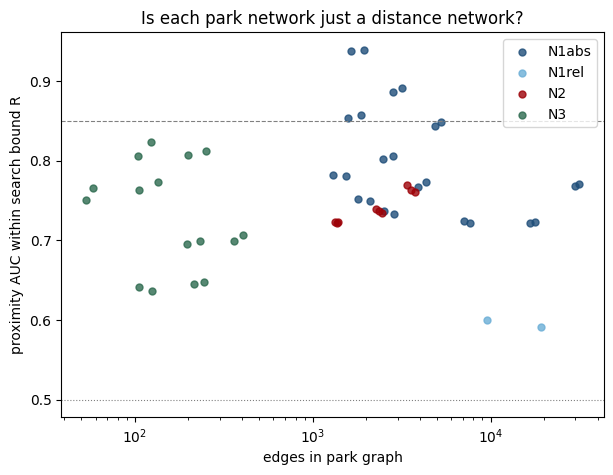

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = {"D": "#7f7f7f", "N1abs": "#1f4e79", "N1rel": "#6baed6", "N2": "#9d0208", "N3": "#2d6a4f"}
for d, g in ev.dropna(subset=["proximity_AUC"]).groupby("definition"):
    ax.scatter(g.edges, g.proximity_AUC, label=d, s=25, color=colors.get(d, "grey"), alpha=0.8)
ax.axhline(0.85, ls="--", color="grey", lw=0.8)
ax.axhline(0.5, ls=":", color="grey", lw=0.8)
ax.set_xscale("log")
ax.set_xlabel("edges in park graph")
ax.set_ylabel("proximity AUC within search bound R")
ax.legend()
ax.set_title("Is each park network just a distance network?")
plt.show()

## 8-4. 사례: 멀지만 연결된 쌍 / 가깝지만 연결되지 않은 쌍 (N1, R=1600, θ=45°)

In [7]:
s_rep = f"N1abs|{PRIMARY}|{DEF_CFG}|R1600|th45|best"
e = EDGE_GROUPS.get(s_rep, edges.iloc[:0])
ek = set(zip(np.minimum(e.i, e.j), np.maximum(e.i, e.j)))
c = pp.copy()
c["edge"] = [k in ek for k in c.index]
name = parks["name"]
far = c[c.edge].sort_values("D_net", ascending=False).head(15)
near = c[~c.edge & (c.D_net < 150)].sort_values("A_1600", ascending=False).head(15)
cases = pd.concat([far.assign(case="far but connected"), near.assign(case="near but not connected")]).reset_index()
cases["name_i"], cases["name_j"] = cases.i.map(name), cases.j.map(name)
cases = cases[["case", "i", "name_i", "j", "name_j", "D_net", "D_euc", "A_1600", "A_3200"]]
cases.to_csv(AREA_DIR / "evaluation_cases.csv", index=False)
cases.round(1)

,case,i,name_i,j,name_j,D_net,D_euc,A_1600,A_3200
0,far but connected,B228,Dr. Green Playground,B419,Sutter Ballfields,1595.300049,1618.2,27.799999,27.799999
1,far but connected,B068,Parade Ground,B148,Rolph Henry Playground,1592.500000,1546.4,24.400000,24.400000
2,far but connected,B260,Howard Playground,B475,Herbal Garden of East NY,1592.500000,1613.0,18.200001,18.200001
3,far but connected,M056,Morningside Park,M392,El Gallo Garden,1589.500000,1540.6,9.300000,9.300000
4,far but connected,Q284,Sixteen Oaks Grove,Q321,Van Alst Playground,1589.400024,1521.5,25.000000,25.000000
5,far but connected,B209,Galapo Playground,B393,Sheepshead Bay Piers,1580.900024,1579.7,7.400000,7.400000
6,far but connected,B293,Classon Playground,B422,Bkln Bears Rockwell Pl Garden,1580.199951,1566.4,15.100000,15.100000
7,far but connected,B023,Lafayette Playground,B400,Hattie Carthan Community Garden,1578.000000,1527.5,0.800000,0.800000
8,far but connected,B023,Lafayette Playground,B140,Banneker Playground,1578.000000,1527.8,0.800000,0.800000
9,far but connected,M204,Moore Playground,M384,Pueblo Unido Garden,1573.699951,1577.4,31.000000,31.000000


## 8-5. 고립 요인 모델 (fractional logit)
종속변수 = IsolationPersistence(0–1). 공원 크기·경계 길이가 고립을 기계적으로 결정하는지, 그리고 OSM 완전성(끊긴 끝점 밀도)과 보도 매핑 regime이 영향을 주는지 확인한다.

In [8]:
P = pd.read_parquet(AREA_DIR / "persistence.parquet")
X = parks.loc[PIDS, ["acres", "perimeter_m", f"n_att_{PRIMARY}", "dangling_per_km2", "sep_share",
                     "street_embedded", "restricted", "typecategory", "borough"]].copy()
X["log_acres"] = np.log(X.acres + 0.01)
X["log_perim"] = np.log(X.perimeter_m + 1)
X["n_att"] = X[f"n_att_{PRIMARY}"]
X["dangling"] = X.dangling_per_km2 / 100
X["street_embedded"] = X.street_embedded.astype(int)
X["restricted"] = X.restricted.astype(int)
model_txt = []
coef_rows = []
for d in ["D", "N1abs", "N1rel", "N2", "N3"]:
    df = X.join(P[[f"{d}_iso"]]).rename(columns={f"{d}_iso": "iso"}).dropna(subset=["iso"])
    f = "iso ~ log_acres + n_att + dangling + sep_share + street_embedded + restricted"
    if len(AREA_BOROUGHS) > 1:
        f += " + C(borough)"
    try:
        res = smf.glm(f, data=df, family=sm.families.Binomial()).fit(cov_type="HC1")
        model_txt.append(f"===== {d} =====\n{res.summary()}\n")
        for k in ["log_acres", "n_att", "dangling", "sep_share", "street_embedded", "restricted"]:
            coef_rows.append({"definition": d, "term": k, "coef": res.params[k], "p": res.pvalues[k]})
    except Exception as ex:
        model_txt.append(f"===== {d} ===== failed: {ex}\n")
(AREA_DIR / "isolation_model.txt").write_text("\n".join(model_txt))
pd.DataFrame(coef_rows).pivot(index="term", columns="definition", values="coef").round(3)

definition,D,N1abs,N1rel,N2,N3
term,,,,,
dangling,-0.053,0.147,0.327,0.074,0.145
log_acres,0.163,0.172,0.198,0.131,0.024
n_att,-0.017,-0.022,-0.021,-0.020,0.019
restricted,-0.097,-0.124,-0.374,-0.077,-0.327
sep_share,-0.244,-0.349,-0.488,-0.284,0.080
street_embedded,-0.021,0.043,0.127,-0.249,0.174
